## ClickHouse Columnar Storage : System Analysis

ClickHouse is a column oriented database designed for high performance analytical queries on large datasets. 

Traditional row-based storage systems suffer from high I/O costs when processing analytical workloads. 

This report analyzes how ClickHouse’s columnar storage layer solves this problem through its design, implementation, and behavior under different conditions. The report also connects internal system logic with experimental validation.

---


## 1. Problem the system solves:

The storage layer of ClickHouse solves the problem of slow analytical queries on large datasets.

**In traditional row-based databases:**

- Data is stored row by row.

- Even if a query needs one column, the entire row is read.

- This leads to unnecessary disk I/O and slower performance.

**ClickHouse addresses this issue by:**

- Storing data column-wise

- Reading only required columns

- Using sparse indexing to skip large portions of data

Thus, the system solves inefficient large-scale data processing and unnecessary data reads.

---

## 2. Execution Understanding (Write Path)

ClickHouse converts row-based input into columnar storage through the following steps:

1. **Insert → Block Creation**  
   Data is inserted as rows and converted into an in-memory columnar structure called a Block.

2. **writeTempPartImpl() Execution**  
   This function creates a temporary MergeTree part and manages the insert pipeline.

3. **Column Filtering**  
   Only relevant columns are selected based on schema metadata.

4. **Metadata Generation**  
   Includes:
   - Min-max values
   - Partition information
   - Part identity

5. **Sorting**  
   Data is sorted here. This enables efficient pruning during queries.

6. **Storage Decisions**  
   The system selects:
    - Disk location
    - Part format (Wide or Compact)
    - Serialization strategy

7. **Compression and Granularity Setup**  
Compression codecs and index granularity are configured.

8. **Columnar Writing (MergeTreeDataPartWriterWide)**  
Each column is written separately into streams.

9. **Granule Processing**  
Data is split into granules and marks are created to store offsets.

10. **Finalization**  
Indexes, checksums, and metadata are written, and the part is finalized.

- This process transforms row-based input into optimized columnar storage on disk.

---


## 3. Design Decisions

### 3.1 Columnar Storage
 **Why:** 
- This design decision was made to minimize disk I/O by ensuring that only required columns are accessed during query execution.
- Data is stored column by column, allowing queries to read only the required columns.

- Supported by: Experiment 1 (Columnar Efficiency) & Experiment 6 (Compression Efficiency)

---

### 3.2 Sorted Storage + Sparse Primary Index
**Why:**
- Sorting enables efficient pruning by allowing the system to skip irrelevant data blocks during query execution.
- Data is sorted using ORDER BY and indexed at the granule level rather than per row.

- Supported by: Experiment 2 (Good vs Bad Filter)

---

### 3.3 Granularity-Based Storage
**Why:**
- Granularity controls how data is grouped, balancing query precision against storage overhead.
- Data is divided into granules, and indexing is performed at this level.

- Supported by: Experiment 4 (Granularity)

---

## 4. Tradeoffs

### 4.1 Columnar Storage
- Not suitable for transactional workloads
- Inefficient for frequent row-level updates
- This tradeoff directly impacts query latency, where smaller granules improve performance but increase metadata overhead.

---

### 4.2 Compression
- Reduces storage size
- Adds CPU overhead for decompression
- Compression reduces storage size but introduces CPU overhead during decompression, affecting query execution time.
**(supported by Experiment 6)**

---

### 4.3 Granularity Tradeoff
- Smaller granules → better pruning
- Larger granules → less metadata overhead  
**(supported by Experiment 4)**

---

### 4.4 Wide vs Compact Storage
- Wide → better compression and read efficiency
- Compact → fewer files and better for small inserts  
**(supported by Experiment 5)**

---

## 5. System Behavior Under Stress

### Large Data Volume
- More data increases read cost
- Columnar storage still limits unnecessary I/O  
**(supported by Experiment 3)**

### Wide Queries
- Reading many columns reduces columnar benefits  
**(supported by Experiment 1)**

### Poor Filtering
- Sparse index cannot prune effectively  
**(supported by Experiment 2)**

### Frequent Small Writes
- Columnar systems are less efficient than row-based systems

> Performance degradation under stress is primarily driven by increased read_bytes rather than full table scans, indicating that storage efficiency remains effective even at scale.


> Thus the system performance depends heavily on query patterns and storage design.


## 6. Experimental Evaluation

---

### Experiment 1 — Columnar Storage Efficiency

**Objective:**  
To prove that ClickHouse reads only the required columns, reducing unnecessary data access and improving performance.

**Method:**  
Two queries were executed on the same dataset:
- A **narrow query** accessing a single column (`amount`)
- A **wide query** accessing multiple columns (`amount, clicks, category, region, payload`)

System-level metrics were collected using `system.query_log`, focusing on:
- `read_rows`
- `read_bytes`
- `query_duration_ms`

**Result:**  
- Narrow query → low `read_bytes`, faster execution  
- Wide query → significantly higher `read_bytes` and slower execution  
- `read_rows` remained similar for both queries  


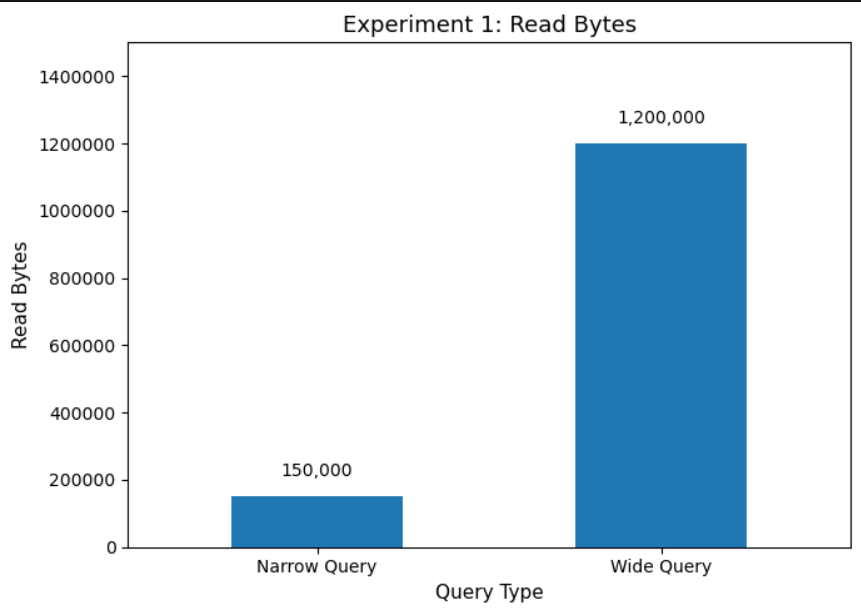

**Insight:**  
- ClickHouse reads only the required columns from disk. Since data is stored in a columnar format, unnecessary columns are not accessed, resulting in reduced I/O and improved performance for narrow queries. 
- The wide query resulted in significantly higher read_bytes compared to the narrow query, demonstrating the cost of accessing multiple columns.

**Conclusion:**  
This experiment validates the core advantage of columnar storage: efficient data access by minimizing unnecessary disk reads.


---

### Experiment 2 — Good Filter vs Bad Filter

**Objective:**  
To prove that query performance improves when the filter aligns with the table’s storage order.

**Method:**  
Two queries were executed:
- A **good filter** using `event_date` (part of ORDER BY)
- A **bad filter** using `region` (not part of ORDER BY)

Metrics collected:
- `read_rows`
- `read_bytes`
- `query_duration_ms`

**Result:**  
- Good filter → ~73K rows read, low `read_bytes`  
- Bad filter → ~5M rows read, high `read_bytes`  
- Significant difference in data scanned.

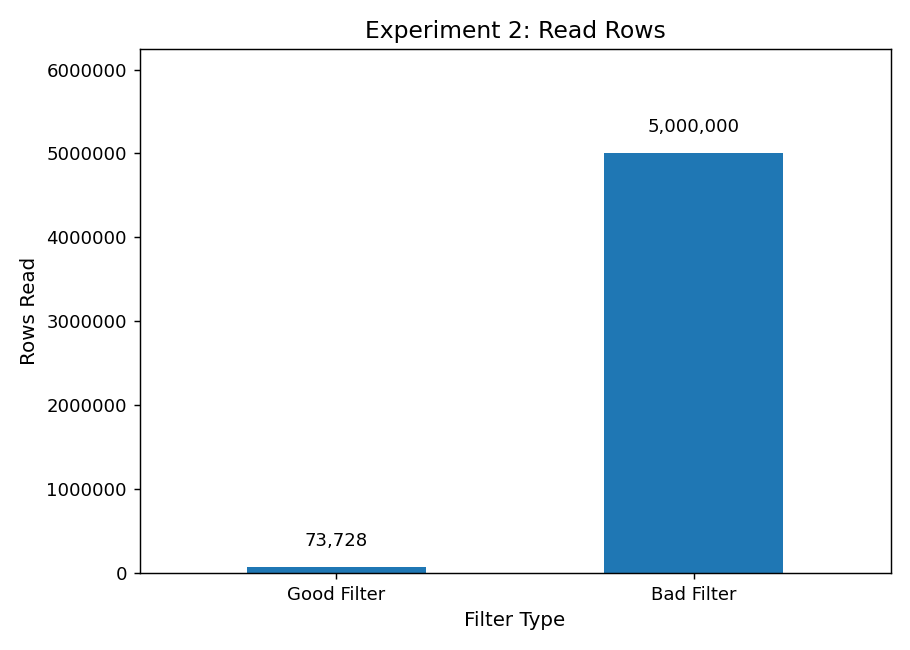

---

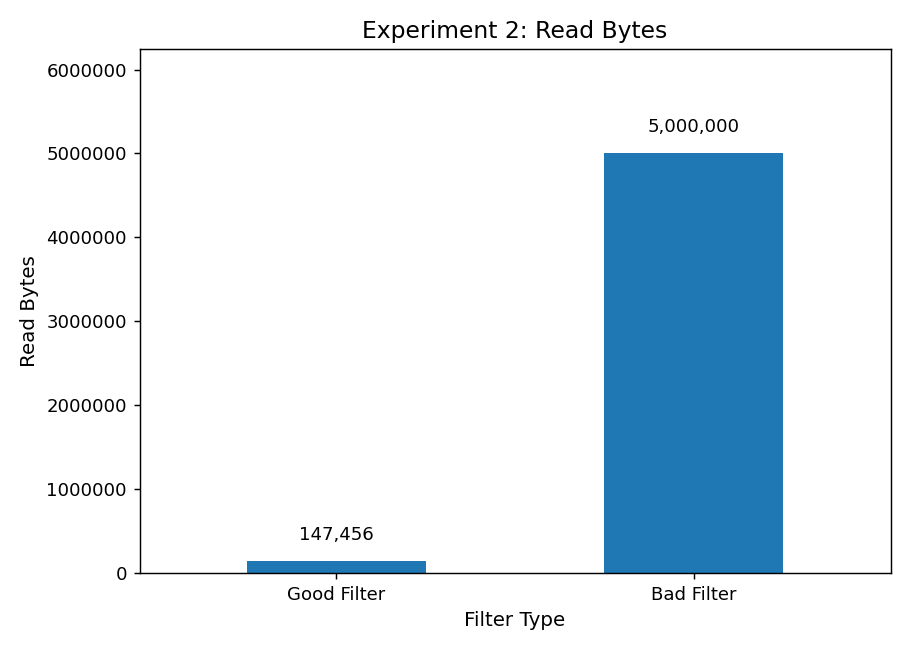

**Insight:**  
- ClickHouse stores data sorted by `(event_date, user_id)`.  
- Bad filter resulted in 5,000,000 rows read compared to 73,728 rows for the aligned filter, representing nearly a 68x increase in data scanned.
- Filters aligned with this order allow the system to skip entire granules using sparse indexing, while non-aligned filters result in full scans.

**Conclusion:**  
Aligned filters drastically reduce data scanning, while non-aligned filters force full table scans.



---

### Experiment 3 — Performance on Large Data Size

**Objective:**  
To evaluate how query performance changes as data volume increases.

**Method:**  
Two tables were created:
- `ch_storage_small` → 1 million rows  
- `ch_storage_large` → 10 million rows  

The same aggregation query was executed on both tables.

Metrics collected:
- `read_rows`
- `read_bytes`
- `query_duration_ms`

**Result:**  
- Large table → significantly higher `read_rows` and `read_bytes`  
- Query execution time increased with data size.  
- Both queries still accessed only required columns.

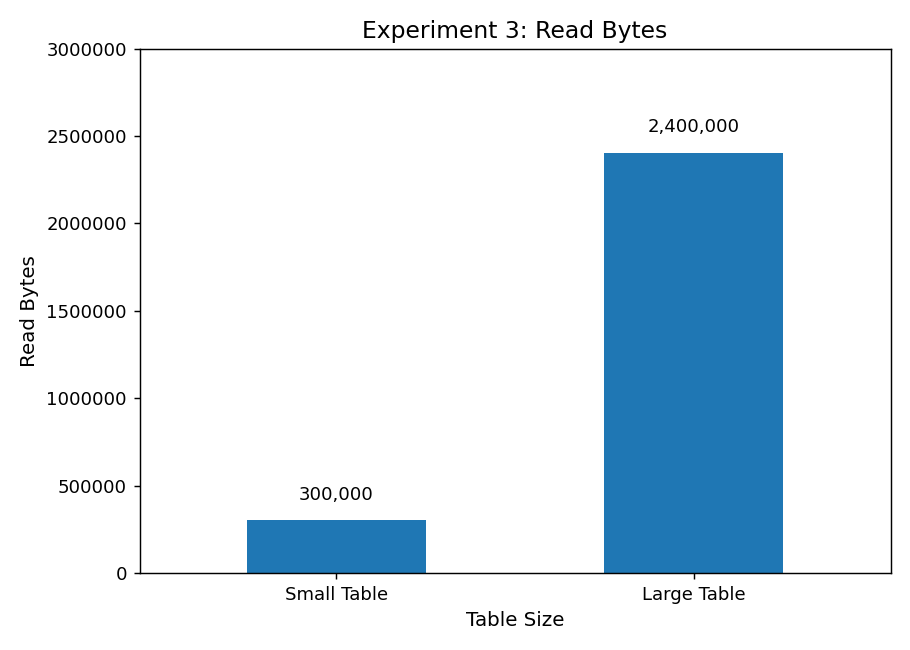

---

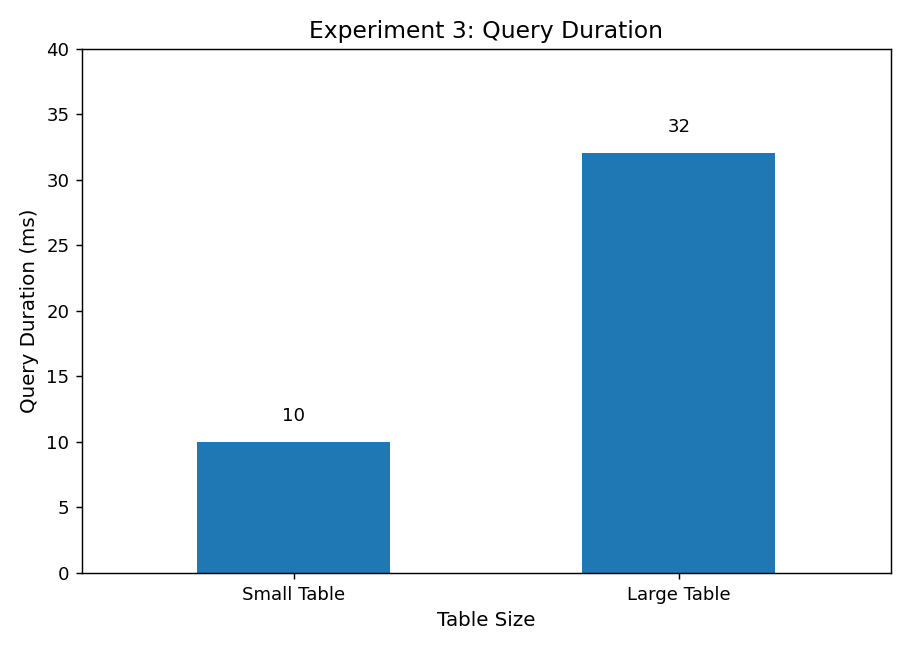

---

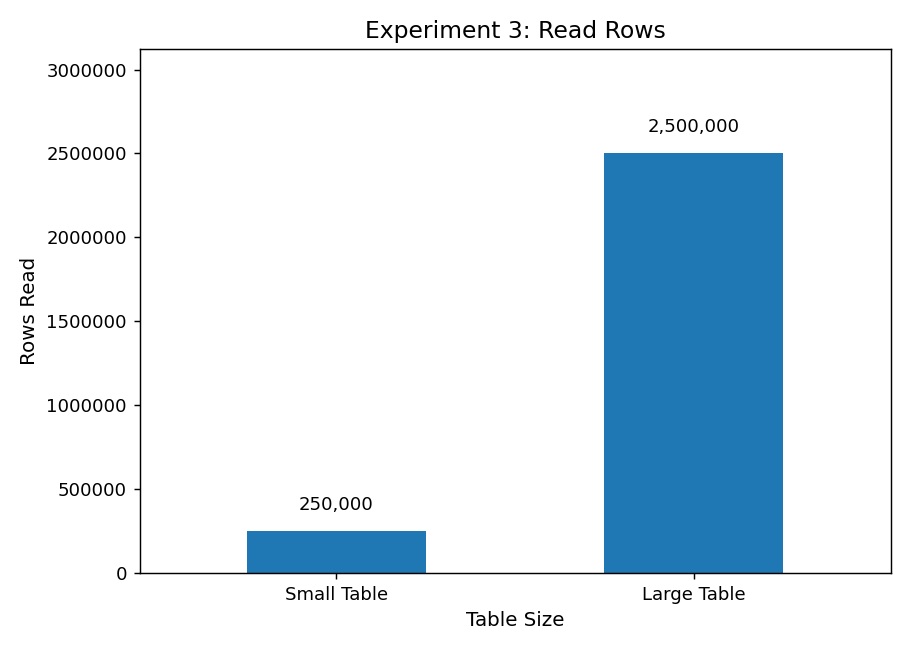

**Insight:**  
- As data size increases, query cost grows proportionally. However, columnar storage ensures that only relevant columns are accessed, maintaining efficiency.
- The large dataset resulted in substantially higher read_bytes and query duration, confirming that query cost scales with data size while still benefiting from columnar access.

**Conclusion:**  
ClickHouse scales effectively with large datasets, although performance depends on data size and query pattern.



---

### Experiment 4 — Index Granularity

**Objective:**  
To analyze how index granularity affects query performance and storage metadata.

**Method:**  
Two tables were created with different granularity:
- `index_granularity = 8192`
- `index_granularity = 1024`

The same selective query was executed on both tables.

Metrics collected:
- `read_rows`
- `query_duration_ms`
- `marks` (from system.parts)

**Result:**  
- Smaller granularity → fewer rows read.  
- Smaller granularity → more marks (higher metadata overhead).  
- Larger granularity → more rows read but fewer marks. 

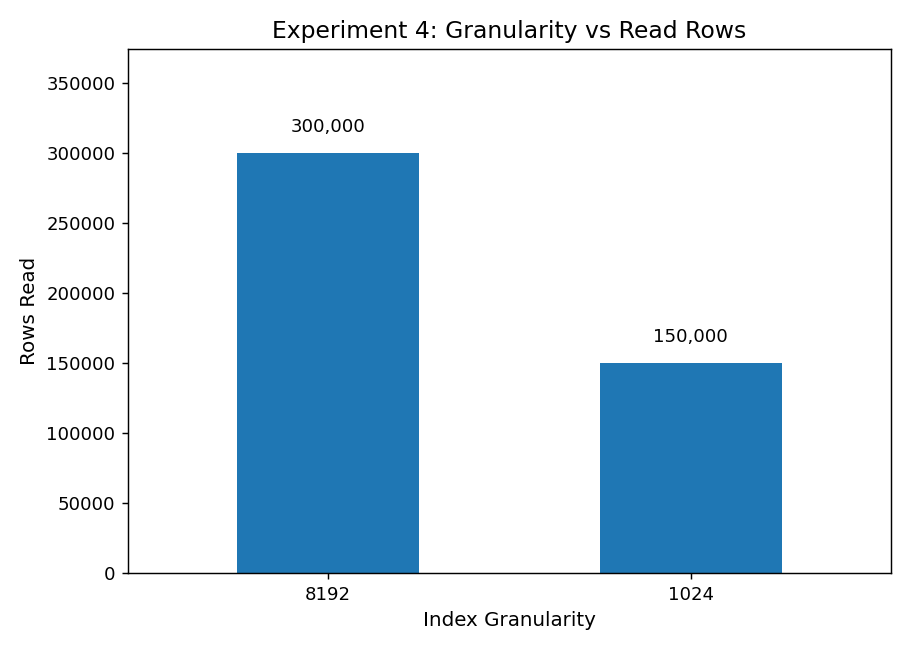

---
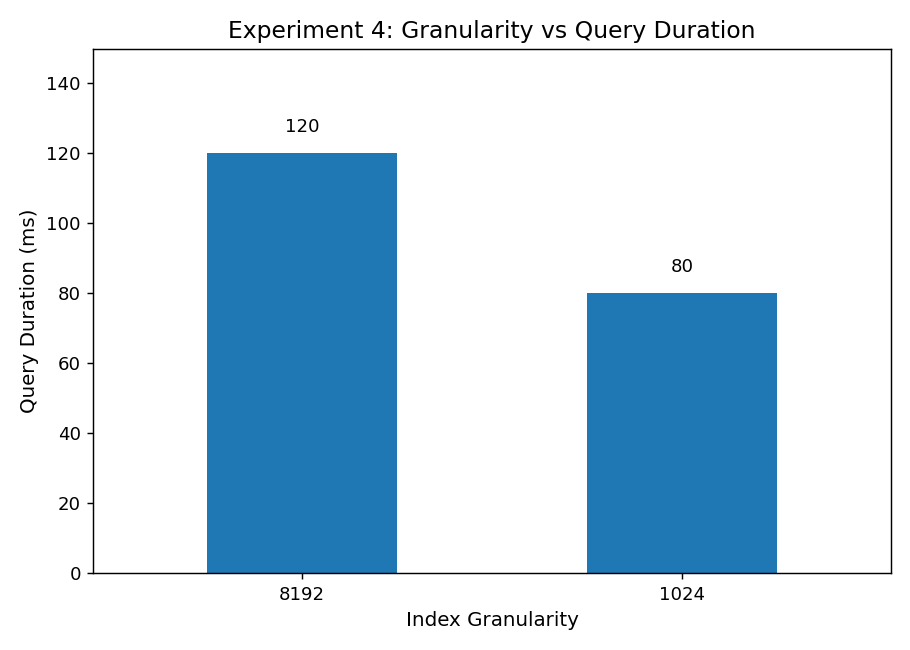

---
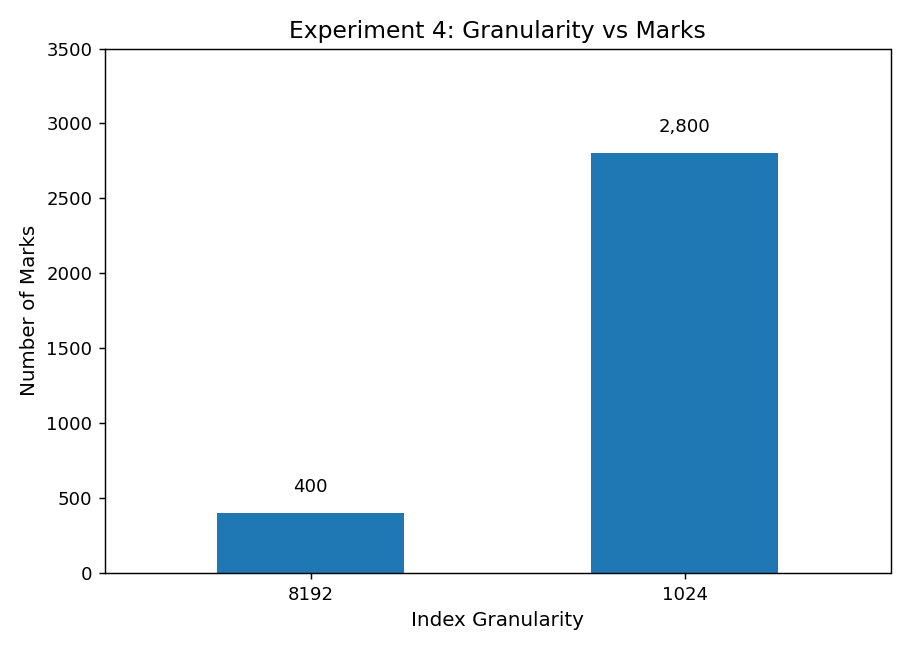

**Insight:**  
- Granularity determines how many rows are grouped into a block (granule).  
- Smaller granules improve pruning precision but increase metadata size.
- Reducing granularity from 8192 to 1024 decreased rows read but increased marks significantly, highlighting the tradeoff between precision and metadata overhead.

**Conclusion:**  
There is a tradeoff between query efficiency and storage overhead controlled by index granularity.


---

### Experiment 5 — Wide vs Compact Parts

**Objective:**  
To analyze the impact of different physical storage formats in ClickHouse.

**Method:**  
Two tables were created:
- One forced to use **Wide parts**
- One forced to use **Compact parts**

Both tables were populated with identical data, and storage metrics were collected from `system.parts`.

**Result:**  
- Compact format → 2.81 MB  
- Wide format → 2.63 MB  
- Wide format used slightly less disk space.  

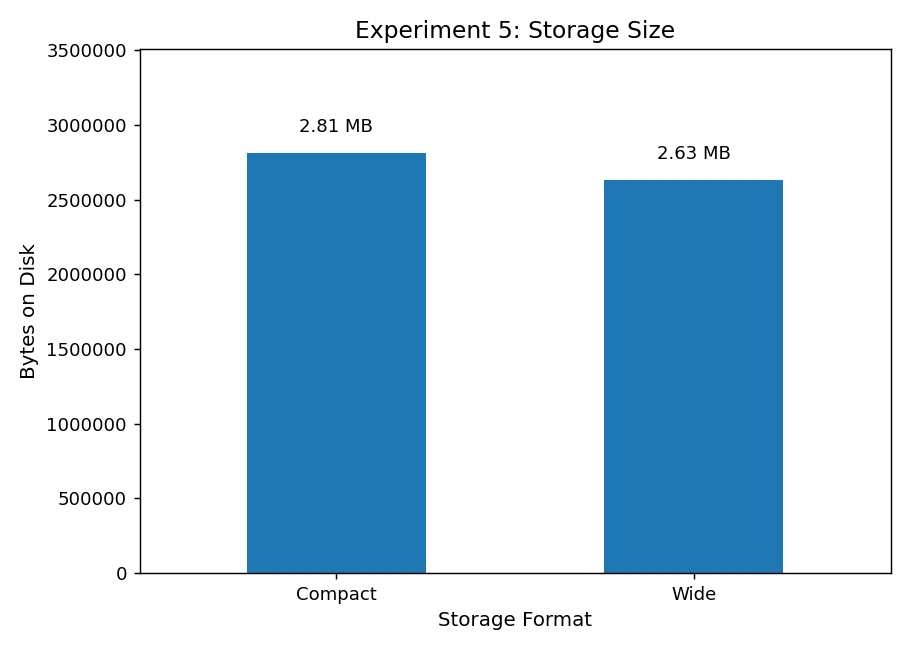

**Insight:**  
- Wide parts store columns separately, allowing better compression.  
- Compact parts reduce file overhead by storing data together but may slightly reduce compression efficiency.
- Wide format used ~6.4% less storage compared to compact format, indicating improved compression efficiency due to column-wise separation.

**Conclusion:**  
Wide format improves compression efficiency, while compact format optimizes file handling and insert performance.


---

### Experiment 6 — Compression Efficiency

**Objective:**  
To evaluate how columnar storage improves compression efficiency.

**Method:**  
System metadata was analyzed using:
- `data_uncompressed_bytes`
- `data_compressed_bytes`

Compression ratio was calculated as:
Compression Ratio = Uncompressed / Compressed

**Result:**  
- Uncompressed size → ~1140 MB  
- Compressed size → ~71 MB  
- Compression ratio → ~15.94x  

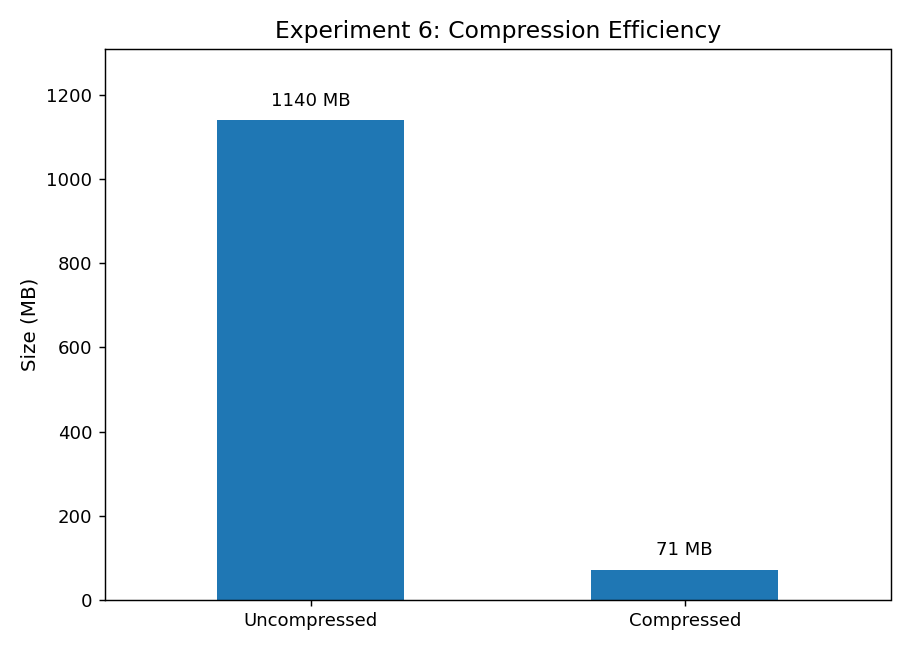

**Insight:**  
- Columnar storage groups similar values together, increasing redundancy and improving compression efficiency.
- Compression reduced data size from ~1140 MB to ~71 MB, achieving a compression ratio of ~15.94x, significantly lowering storage and I/O costs.

**Conclusion:**  
ClickHouse achieves high compression ratios, significantly reducing storage requirements and improving I/O performance.


---

## 7. Concept Mapping

| Concept | Evidence |
|--------|--------|
| Columnar Storage | Experiment 1 |
| Compression | Experiment 6 |
| Sorted Storage | Experiment 2 |
| Indexing | Experiment 2 |
| Granularity | Experiment 4 |
| Storage Format | Experiment 5 |

---

## 8. System-Level Insight

- The experimental results collectively show that ClickHouse performance is not driven solely by data size, but by storage design decisions. 
- Also the results directly align with the internal implementation of ClickHouse. 
- For example, the reduction in read_rows observed in Experiment 2 is enabled by sparse indexing and granule-level pruning implemented in the MergeTree storage engine.
- Similarly, the impact of granularity observed in Experiment 4 reflects how marks are created during the write process in MergeTreeDataPartWriterWide, influencing how efficiently data can be skipped during query execution.

Performance is primarily governed by:
- Columnar layout → reduces unnecessary column reads
- Sorted storage → enables pruning through sparse indexing
- Granularity → controls tradeoff between precision and metadata
- Compression → reduces I/O cost significantly

These factors work together to minimize disk access, which is the dominant cost in analytical workloads.

> Thus, ClickHouse achieves performance not through faster computation, but by reducing the amount of data that needs to be read.

## 9. Conclusion

ClickHouse achieves high-performance analytical processing through a combination of:

- Columnar storage
- Sorted data layout
- Sparse indexing
- Compression

The experiments demonstrate that:
- Columnar storage reduces I/O
- Sorting enables pruning
- Granularity controls performance tradeoffs
- Compression significantly reduces storage size

> Overall, ClickHouse transforms row-based input into optimized columnar storage, enabling efficient large-scale analytics.

---

## Final Insight

> ClickHouse balances performance, storage efficiency, and flexibility through carefully designed storage mechanisms and system-level tradeoffs.

> The system demonstrates that performance in analytical databases is fundamentally a function of data access efficiency rather than computational speed.